# Análisis Exploratorio de Datos (EDA)

## Modelo Predictivo de Supervivencia en el Titanic

**Grupo 3** | Santiago Acevedo González, Ivan Rene Acosta Lallemand, Daniela Andrea Gallego Díaz

En este notebook se explora el dataset del Titanic con el objetivo de entender su estructura, identificar los
valores faltantes, revisar las estadísticas descriptivas, medir la correlación entre variables numéricas y
visualizar cómo se relacionan las principales características con la supervivencia de los pasajeros.

## Introducción

El 15 de abril de 1912 el RMS Titanic se hundió durante su viaje inaugural tras chocar con un iceberg, causando
la muerte de 1502 de las 2224 personas a bordo. Este proyecto busca construir un modelo de clasificación
supervisada que prediga si un pasajero sobrevivió (`Survived = 1`) o no (`Survived = 0`).

La **variable objetivo** es `Survived`. Las variables predictoras iniciales incluyen factores demográficos
(`Age`, `Sex`), socioeconómicos (`Pclass`, `Fare`) y familiares (`SibSp`, `Parch`), entre otros.

Para empezar, se organizan los datos, se explora su estructura y se extraen conclusiones preliminares que
servirán de base para decidir cómo preprocesar la información y qué características conviene utilizar.

### Configuración del entorno

El proyecto gestiona dependencias con `uv`. Los datos crudos se encuentran en `../data/raw/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme("notebook", style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
DATA_RAW = "../data/raw"

train = pd.read_csv(f"{DATA_RAW}/train.csv")
test = pd.read_csv(f"{DATA_RAW}/test.csv")

print(f"train: {train.shape} | test: {test.shape}")

train: (891, 12) | test: (418, 11)


## Descripción del dataset

El conjunto `train.csv` contiene **891 pasajeros** y **12 columnas**; `test.csv` contiene **418 pasajeros** y
**11 columnas** (sin la variable objetivo `Survived`, que es lo que debe predecirse). A continuación se describe
la estructura, los tipos de datos y la cantidad de valores faltantes por columna.

In [3]:
column_info = pd.DataFrame({
    "Tipo": train.dtypes.astype(str),
    "No nulos": train.notna().sum(),
    "Nulos": train.isna().sum(),
    "Porcentaje nulos (%)": (train.isna().mean() * 100).round(2),
})
column_info

,Tipo,No nulos,Nulos,Porcentaje nulos (%)
PassengerId,int64,891,0,0.00
Survived,int64,891,0,0.00
Pclass,int64,891,0,0.00
Name,object,891,0,0.00
Sex,object,891,0,0.00
Age,float64,714,177,19.87
SibSp,int64,891,0,0.00
Parch,int64,891,0,0.00
Ticket,object,891,0,0.00
Fare,float64,891,0,0.00


In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Dimensiones y valores faltantes

El dataset de entrenamiento tiene **891 filas y 12 columnas**. La cantidad de valores faltantes por columna es:

| Columna  | Nulos | Porcentaje |
|----------|-------:|-----------:|
| `Age`     | 177   | 19.87%     |
| `Cabin`   | 687   | 77.10%     |
| `Embarked`| 2     | 0.22%      |

`Cabin` tiene más de tres cuartas partes de sus valores faltantes, por lo que en el preprocesamiento conviene
descartarla o transformarla en una variable binaria (tener o no cabina). `Age` requiere imputación o segmentación
apoyada en otras variables, y `Embarked` solo tiene 2 registros sin valor que pueden completarse con la moda.

In [6]:
nulos = train.isna().sum()
nulos = nulos[nulos > 0].to_frame("Nulos")
nulos["Porcentaje (%)"] = (train.isna().mean() * 100).round(2).loc[nulos.index]
nulos

,Nulos,Porcentaje (%)
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


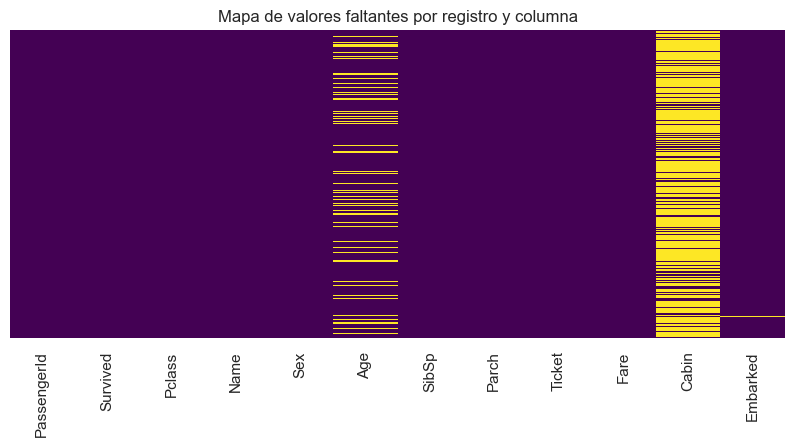

In [7]:
plt.figure(figsize=(10, 4))
sns.heatmap(train.isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Mapa de valores faltantes por registro y columna")
plt.show()

### Estadísticas descriptivas

La tasa global de supervivencia es del **38.4%** (la media de `Survived`, siendo una variable binaria). La edad
promedio es de **~29.7 años** (rango 0.42-80) y la tarifa promedio es de **~32.2**. La clase predominante es la 3
(mediana de `Pclass` igual a 3), lo que refleja que la mayoría de los pasajeros viajaba en tercera clase.

In [8]:
train[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].describe().round(2)

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


### Variable objetivo: `Survived`

El dataset está desbalanceado: aproximadamente el **61.6%** de los pasajeros no sobrevivió frente al **38.4%** que
sí lo hizo. Este desbalance conviene tenerlo presente a la hora de elegir la métrica de evaluación (por ejemplo,
exactitud balanceada, F1 o AUC) y de calibrar el modelo.

In [9]:
train['Survived'].value_counts(normalize=True).round(4).to_frame('Proporción')

,Proporción
Survived,
0,0.62
1,0.38


/var/folders/d5/x306j9ld6pb923vdldl5w3980000gn/T/ipykernel_97285/3084514118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x="Survived", palette="Set2")


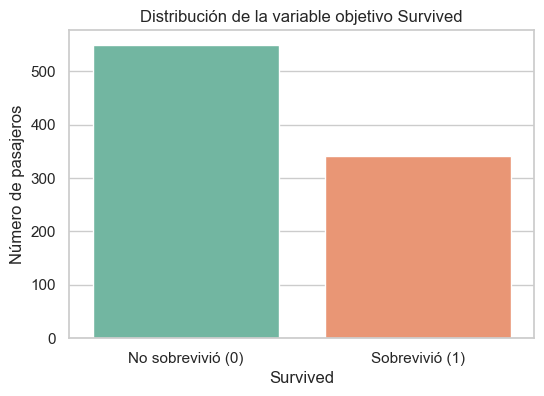

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train, x="Survived", palette="Set2")
plt.title("Distribución de la variable objetivo Survived")
plt.xticks([0, 1], ["No sobrevivió (0)", "Sobrevivió (1)"])
plt.ylabel("Número de pasajeros")
plt.show()

### Análisis de correlación entre variables numéricas

Las correlaciones más relevantes con `Survived` son **`Pclass` (-0.338)** y **`Fare` (+0.257)**: a mayor clase
(1ª) y mayor tarifa, mayor probabilidad de supervivencia. La `Age` tiene una correlación débil (-0.077) con la
supervivencia. Se observa además una fuerte correlación negativa entre `Pclass` y `Fare` (-0.549), coherente con
que las clases superiores pagan tarifas más altas.

In [11]:
cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = train[cols].corr()
corr['Survived'].sort_values(ascending=False).round(3)

Survived    1.00
Fare        0.26
Parch       0.08
SibSp      -0.04
Age        -0.08
Pclass     -0.34
Name: Survived, dtype: float64

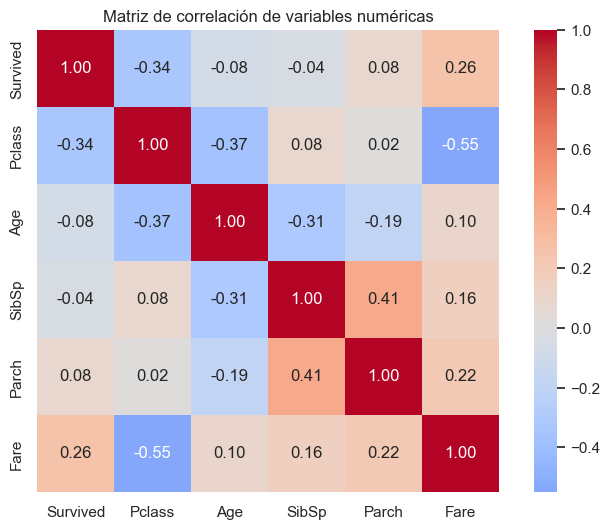

In [12]:
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

### Supervivencia según género (`Sex`)

El **74.2%** de las mujeres sobrevivió frente a solo el **18.9%** de los hombres. El género es un diferenciador
muy fuerte de la supervivencia y será una característica clave para el modelo.

In [13]:
sex_survival = train.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean']).round(4)
sex_survival.columns = ['Total', 'Sobrevivientes', 'Tasa de supervivencia']
sex_survival

,Total,Sobrevivientes,Tasa de supervivencia
Sex,,,
female,314,233,0.74
male,577,109,0.19


/var/folders/d5/x306j9ld6pb923vdldl5w3980000gn/T/ipykernel_97285/1333035262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train, x="Sex", y="Survived", errorbar=None, palette="husl")


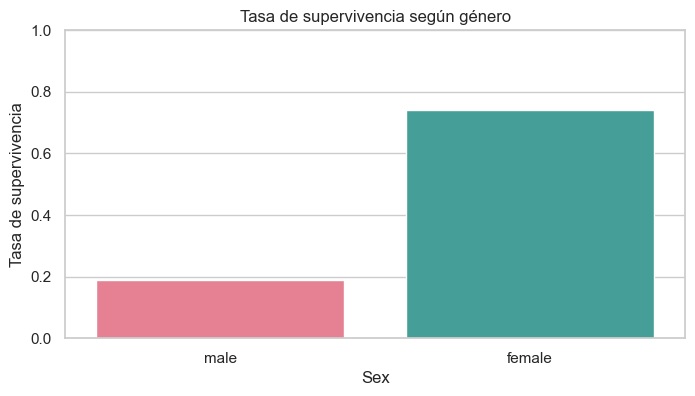

In [14]:
plt.figure(figsize=(8, 4))
sns.barplot(data=train, x="Sex", y="Survived", errorbar=None, palette="husl")
plt.title("Tasa de supervivencia según género")
plt.ylabel("Tasa de supervivencia")
plt.ylim(0, 1)
plt.show()

### Supervivencia según clase (`Pclass`)

La tasa de supervivencia decrece con la clase: **63.0%** en 1ª, **47.3%** en 2ª y **24.2%** en 3ª. La clase
socioeconómica es otro predictor relevante, en línea con el análisis de correlación.

In [15]:
pclass_survival = train.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean']).round(4)
pclass_survival.columns = ['Total', 'Sobrevivientes', 'Tasa de supervivencia']
pclass_survival

,Total,Sobrevivientes,Tasa de supervivencia
Pclass,,,
1,216,136,0.63
2,184,87,0.47
3,491,119,0.24


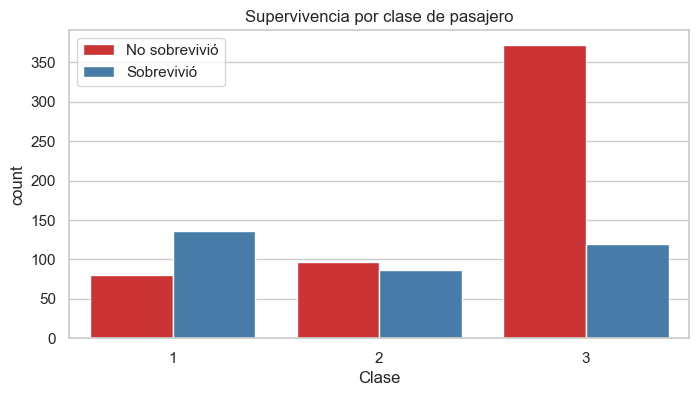

In [16]:
plt.figure(figsize=(8, 4))
sns.countplot(data=train, x="Pclass", hue="Survived", palette="Set1")
plt.title("Supervivencia por clase de pasajero")
plt.xlabel("Clase")
plt.legend(["No sobrevivió", "Sobrevivió"])
plt.show()

### Supervivencia según puerto de embarque (`Embarked`)

Los pasajeros embarcados en **Cherburgo (C)** sobrevivieron más (**55.4%**), seguidos de **Queenstown (Q)** con
**39.0%** y **Southampton (S)** con **33.7%**. La diferencia entre puertos puede estar confundida con la clase
social, por lo que conviene analizarla en conjunto con `Pclass`.

In [17]:
embarked_survival = train.groupby('Embarked')['Survived'].agg(['count', 'sum', 'mean']).round(4)
embarked_survival.columns = ['Total', 'Sobrevivientes', 'Tasa de supervivencia']
embarked_survival

,Total,Sobrevivientes,Tasa de supervivencia
Embarked,,,
C,168,93,0.55
Q,77,30,0.39
S,644,217,0.34


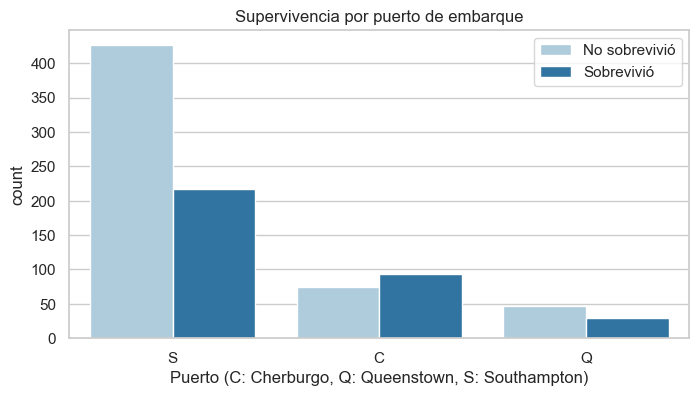

In [18]:
plt.figure(figsize=(8, 4))
sns.countplot(data=train, x="Embarked", hue="Survived", palette="Paired")
plt.title("Supervivencia por puerto de embarque")
plt.xlabel("Puerto (C: Cherburgo, Q: Queenstown, S: Southampton)")
plt.legend(["No sobrevivió", "Sobrevivió"])
plt.show()

### Interacción entre variables: `Sex` y `Pclass`

La tasa de supervivencia combinando género y clase muestra patrones extremos: las mujeres de 1ª y 2ª clase
sobrevivieron mayoritariamente, mientras que los hombres de 2ª y 3ª clase tuvieron la menor tasa.

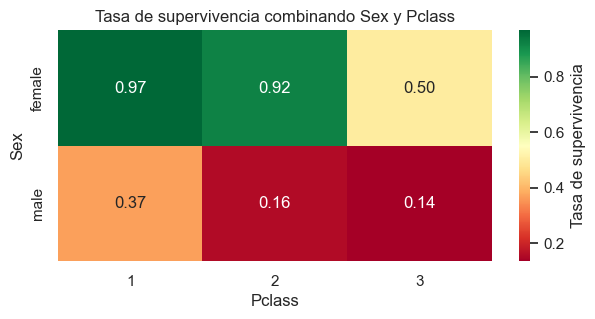

In [19]:
pivot = train.pivot_table(index="Sex", columns="Pclass", values="Survived")
plt.figure(figsize=(7, 3))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={"label": "Tasa de supervivencia"})
plt.title("Tasa de supervivencia combinando Sex y Pclass")
plt.show()

## Conclusiones

1. `Survived` está **desbalanceado** (38.4% sobrevive); conviene elegir una métrica de evaluación adecuada a esta condición.
2. **Nulos**: `Cabin` (~77%) probablemente convenga descartarla o convertirla en una variable binaria; `Age` (~20%) necesita imputación; `Embarked` (2 registros) puede completarse con la moda.
3. Las variables con mayor poder predictivo parecen ser **`Sex`**, **`Pclass`**, **`Fare`** y la interacción **`Sex` + `Pclass`**.
4. `Age` y las variables familiares (`SibSp`, `Parch`) aportan información modesta, aunque pueden resultar útiles en el modelo.
5. En el preprocesamiento será necesario codificar las variables categóricas, imputar los valores faltantes según el caso. Debido a que el modelo seleccionado es un Random Forest, no es necesario escalar las variables numéricas.

Con esta base queda claro hacia dónde apuntar: el género y la clase social son los factores que más influyen en
la supervivencia, y cualquier transformación posterior debe preservar esa información.

---

## Preprocesamiento de datos

A continuación se realiza la división del dataset y el preprocesamiento necesario para el modelado.

## Prevención de fuga de información (Data Leakage)

Antes de aplicar cualquier transformación sobre los datos (imputación, codificación o escalado), es fundamental
dividir el conjunto de entrenamiento original en un subconjunto de **entrenamiento** (80%) y uno de **prueba** (20%).

**¿Qué es la fuga de información?**

La fuga de información (*data leakage*) ocurre cuando el modelo tiene acceso indirecto a datos del conjunto de
prueba durante el entrenamiento, lo que genera métricas de evaluación artificialmente optimistas que no reflejan
el rendimiento real del modelo con datos nuevos.

Un error común es calcular estadísticas (como la media para imputar valores faltantes, o los parámetros de un
escalador) sobre **todo** el dataset antes de separar en entrenamiento y prueba. Si la media de `Age` se calcula
incluyendo los registros de prueba, el modelo recibe información indirecta de esos registros, sesgando la
evaluación.

**Flujo correcto:**

1. Dividir en `X_train` / `X_test` (y `y_train` / `y_test`) **antes** de cualquier transformación.
2. Ajustar (*fit*) imputadores, codificadores y escaladores **únicamente** sobre `X_train`.
3. Aplicar (*transform*) esas mismas transformaciones a `X_test` con los parámetros aprendidos del entrenamiento.

De esta forma, el conjunto de prueba permanece "intacto" y sirve como una estimación honesta del desempeño
del modelo ante datos nunca vistos.

**División estratificada:** Se utiliza `train_test_split` con `stratify=y` para preservar la proporción de la
variable objetivo (`Survived`) en ambos subconjuntos. Dado que la supervivencia está desbalanceada (~38.4% vs
~61.6%), la estratificación garantiza que tanto el conjunto de entrenamiento como el de prueba representen
fielmente esta distribución, evitando que algún subconjunto quede sobre-representado por una clase.

In [20]:
from sklearn.model_selection import train_test_split

SEED = 42

X = train.drop(columns=["Survived"])
y = train["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train distribución:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"y_test distribución:\n{y_test.value_counts(normalize=True).round(4)}")

X_train: (712, 11) | X_test: (179, 11)
y_train distribución:
Survived
0   0.62
1   0.38
Name: proportion, dtype: float64
y_test distribución:
Survived
0   0.61
1   0.39
Name: proportion, dtype: float64


### Estrategia de imputación de valores faltantes

Como se identificó en el EDA, las únicas columnas con valores faltantes en el conjunto de
entrenamiento son `Age`, `Cabin` y `Embarked`:

| Columna    | Nulos | Porcentaje |
|------------|------:|-----------:|
| `Age`      | 177   | 19.87%     |
| `Cabin`    | 687   | 77.10%     |
| `Embarked` | 2     | 0.22%      |

**`Age` → mediana.** Es una variable numérica continua con ~20% de nulos. La **mediana** es robusta
frente a valores atípicos y representa el valor central típico del pasajero, a diferencia de la
media, que se vería distorsionada por edades extremas.

**`Embarked` → moda.** Es una variable categórica nominal (puerto de embarque) y solo 2 registros
carecen de valor. La **moda** (la categoría más frecuente, `S` = Southampton) es la estrategia
adecuada para completar un nulo categórico minoritario.

### Tratamiento de la variable `Cabin`

`Cabin` presenta **687 de 891 valores faltantes (77.10%)** en `train`. Imputarla con una medida de
tendencia central no tiene sentido: es un identificador de **alta cardinalidad** (147 valores
distintos en los 204 registros no nulos) y un valor imputado no representaría la cabina real del
pasajero.

**Decisión: se elimina la columna `Cabin`.** De forma análoga se descartan `PassengerId`, `Name` y
`Ticket`, que también son identificadores únicos por pasajero y, de mantenerse, provocarían
sobreajuste sin aportar poder predictivo generalizable.

### Codificación de variables categóricas con `OneHotEncoder`

`Sex` (2 categorías: `male`, `female`) y `Embarked` (3 categorías: `C`, `Q`, `S`) son variables
categóricas nominales. Se codifican con **`OneHotEncoder`**, que genera una columna binaria por
categoría sin imponer un orden inexistente entre ellas.

El codificador se ajusta únicamente sobre `X_train`, de modo que las categorías reconocidas son las
presentes en el entrenamiento, y con `handle_unknown="ignore"` se garantiza que un nivel inédito
en el conjunto de prueba no rompa el pipeline.

### Pipeline de preprocesamiento (`ColumnTransformer`)

Todos los pasos se integran en un único `ColumnTransformer` de Scikit-Learn:

- **Bloque `num`**: `SimpleImputer(strategy="median")` sobre `Pclass`, `Age`, `SibSp`, `Parch` y `Fare`.
  Cada columna numérica se imputa con su propia mediana calculada en `X_train`.
- **Bloque `cat`**: `SimpleImputer(strategy="most_frequent")` seguido de `OneHotEncoder` sobre `Sex` y `Embarked`.
- **`remainder="drop"`**: elimina las columnas no declaradas (`PassengerId`, `Name`, `Ticket`, `Cabin`).

El pipeline solo se ajusta (*fit*) con `X_train`; `X_test` únicamente se transforma con los
parámetros aprendidos del entrenamiento.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [22]:
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

preprocessor.fit(X_train)

feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(preprocessor.transform(X_train), columns=feature_names)
X_test_processed = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names)

print(f"X_train_processed: {X_train_processed.shape} | X_test_processed: {X_test_processed.shape}")
print(f"Columnas generadas: {list(X_train_processed.columns)}")

X_train_processed: (712, 10) | X_test_processed: (179, 10)
Columnas generadas: ['num__Pclass', 'num__Age', 'num__SibSp', 'num__Parch', 'num__Fare', 'cat__Sex_female', 'cat__Sex_male', 'cat__Embarked_C', 'cat__Embarked_Q', 'cat__Embarked_S']


In [23]:
nulos_train = int(X_train_processed.isna().sum().sum())
nulos_test = int(X_test_processed.isna().sum().sum())

print(f"Valores nulos en X_train_processed: {nulos_train}")
print(f"Valores nulos en X_test_processed: {nulos_test}")
assert nulos_train == 0, "X_train tiene valores nulos"
assert nulos_test == 0, "X_test tiene valores nulos"

print("Mediana de Age (train):", X_train["Age"].median())
print("Moda de Embarked (train):", X_train["Embarked"].mode().iloc[0])
X_train_processed.head()

Valores nulos en X_train_processed: 0
Valores nulos en X_test_processed: 0
Mediana de Age (train): 28.5
Moda de Embarked (train): S


,num__Pclass,num__Age,num__SibSp,num__Parch,num__Fare,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S
0,3.00,28.50,0.00,0.00,56.50,0.00,1.00,0.00,0.00,1.00
1,2.00,28.50,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
2,1.00,28.50,0.00,0.00,221.78,0.00,1.00,0.00,0.00,1.00
3,3.00,18.00,0.00,1.00,9.35,1.00,0.00,0.00,0.00,1.00
4,2.00,31.00,1.00,1.00,26.25,1.00,0.00,0.00,0.00,1.00


### Resumen del preprocesamiento

- El `ColumnTransformer` transforma `X_train` (712 filas) y `X_test` (179 filas) sin errores.
- **Cero valores faltantes** en las variables procesadas.
- Todos los estadísticos (mediana de `Age`, moda de `Embarked`) y las categorías del `OneHotEncoder`
  se aprendieron únicamente sobre `X_train`, de modo que `X_test` solo fue transformado con
  parámetros del entrenamiento (sin fuga de información).
- `Cabin` se descartó por su **77.10%** de nulos y su alta cardinalidad.
- Las variables resultantes (numéricas imputadas + categóricas _one-hot_) alimentarán al modelo base
  que se entrena y evalúa a continuación.

## Modelo base: `DummyClassifier`

Antes de entrenar un modelo real, se define un **punto de referencia (baseline)** con un
`DummyClassifier(strategy="most_frequent")`. Esta estrategia ignora las variables predictoras y
siempre predice la **clase mayoritaria** observada en `y_train`. Como se detectó en el EDA,
`Survived` está desbalanceado (~61.6% sin supervivencia vs ~38.4% supervivencia), así que el
baseline predecirá sistemáticamente clase `0` (no sobrevivió).

Las métricas de este modelo sencillo quedan guardadas como **referencia comparativa**: cualquier
modelo posterior debe superarlas para justificar su utilidad real.

In [24]:
import json
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [25]:
base_model = DummyClassifier(strategy="most_frequent")
base_model.fit(X_train_processed, y_train)

print("Clase predictora (única):", base_model.classes_)

Clase predictora (única): [0 1]


In [26]:
y_pred_base = base_model.predict(X_test_processed)

print(f"Predicciones: {len(y_pred_base)}")
print("Distribución de y_pred_base:")
print(pd.Series(y_pred_base).value_counts())

Predicciones: 179
Distribución de y_pred_base:
0    179
Name: count, dtype: int64


In [27]:
metricas_base = {
    "modelo": "DummyClassifier",
    "estrategia": "most_frequent",
    "accuracy": round(accuracy_score(y_test, y_pred_base), 4),
    "precision": round(precision_score(y_test, y_pred_base, zero_division=0), 4),
    "recall": round(recall_score(y_test, y_pred_base, zero_division=0), 4),
    "f1_score": round(f1_score(y_test, y_pred_base, zero_division=0), 4),
}

tabla_metricas = pd.DataFrame(
    [
        ["Accuracy", metricas_base["accuracy"]],
        ["Precision", metricas_base["precision"]],
        ["Recall", metricas_base["recall"]],
        ["F1-Score", metricas_base["f1_score"]],
    ],
    columns=["Métrica", "Valor"],
)
tabla_metricas.round(4)

,Métrica,Valor
0,Accuracy,0.61
1,Precision,0.00
2,Recall,0.00
3,F1-Score,0.00


In [28]:
ruta_metricas = Path("metricas_base.json")
ruta_metricas.write_text(json.dumps(metricas_base, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Métricas base guardadas en: {ruta_metricas.resolve()}")
print(json.dumps(metricas_base, indent=2, ensure_ascii=False))

Métricas base guardadas en: /Users/danielagallego/Documents/Modelos1Proyecto/modelo-titanic-g3/fase-1/metricas_base.json
{
  "modelo": "DummyClassifier",
  "estrategia": "most_frequent",
  "accuracy": 0.6145,
  "precision": 0.0,
  "recall": 0.0,
  "f1_score": 0.0
}


### Resumen del modelo base

- Se entrenó un `DummyClassifier(strategy="most_frequent")` que **siempre predice la clase
  mayoritaria** (`0` = no sobrevivió), ignorando las variables predictoras.
- La **Accuracy** resulta ~igual a la proporción de no supervivientes en el test (~61.6%): el baseline
  simplemente acierta todo lo que no sobrevive y falla todo lo que sobrevive.
- **Precision, Recall y F1-Score** (con la supervivencia como clase positiva) son **0**, porque el
  baseline nunca predice supervivencia. Son la cota mínima que los modelos posteriores deben superar.
- Las métricas quedaron guardadas en **`fase-1/metricas_base.json`** como punto de referencia
  comparativo para las siguientes iteraciones.

---

## Modelo principal: `RandomForestClassifier`

Se entrena el modelo de clasificación supervisada principal del proyecto, ensamblado dentro del **Pipeline general** de Scikit-Learn. Se elige **`RandomForestClassifier`** porque:

- Maneja bien variables numéricas y categóricas codificadas (one-hot) sin requerir escalado.
- Captura relaciones **no lineales** e **interacciones** entre características (p. ej. `Sex` × `Pclass`).
- Es robusto frente al sobreajuste gracias al *bagging* y permite inspeccionar la **importancia de las características**.

**Evitar la fuga de información:** el `ColumnTransformer` de preprocesamiento se integra como primer paso del Pipeline. Así, cada pliegue de la **validación cruzada** recalcula las imputaciones (mediana, moda) y la codificación únicamente con el subconjunto de entrenamiento de ese pliegue, nunca con la partición de validación.

**Ajuste de hiperparámetros:** se usa `GridSearchCV` con `StratifiedKFold` de **5 pliegues** sobre **únicamente** `X_train` / `y_train`, explorando hiperparámetros básicos del bosque: `n_estimators`, `max_depth`, `min_samples_split` y `min_samples_leaf`. La estratificación preserva la proporción de supervivientes (~38.4%) en cada pliegue.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipeline_modelo = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    ]
)

param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 5, 10],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    pipeline_modelo,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"Accuracy media CV (5 pliegues): {grid_search.best_score_:.4f}")

Mejores hiperparámetros: {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Accuracy media CV (5 pliegues): 0.8188


### Resultados de la validación cruzada

`GridSearchCV` evalúa cada combinación de hiperparámetros con validación cruzada estratificada de 5 pliegues sobre los datos de entrenamiento. A continuación se muestran las **5 mejores combinaciones** ordenadas por accuracy media (`mean_test_score`), con su desviación estándar (`std_test_score`) como indicador de estabilidad entre pliegues.

In [30]:
resultados_cv = pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score")
resultados_cv[["rank_test_score", "mean_test_score", "std_test_score", "params"]].head(5)

,rank_test_score,mean_test_score,std_test_score,params
12,1,0.82,0.02,"{'clf__max_depth': 5, 'clf__min_samples_leaf':..."
21,2,0.82,0.03,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
20,2,0.82,0.02,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
22,4,0.82,0.02,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
16,5,0.82,0.02,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."


### Evaluación del mejor modelo en `X_test`

Una vez fijados los hiperparámetros con validación cruzada, el mejor modelo se reajusta con todo `X_train` (`refit=True`) y se evalúa **una única vez** sobre el conjunto de prueba retenido (`X_test`), que no participó en ningún paso del entrenamiento.

In [31]:
y_pred_modelo = grid_search.best_estimator_.predict(X_test)

metricas_modelo = {
    "modelo": "RandomForestClassifier",
    "estrategia": "Pipeline + GridSearchCV (StratifiedKFold 5)",
    "mejores_hiperparametros": grid_search.best_params_,
    "accuracy_cv": round(grid_search.best_score_, 4),
    "accuracy": round(accuracy_score(y_test, y_pred_modelo), 4),
    "precision": round(precision_score(y_test, y_pred_modelo, zero_division=0), 4),
    "recall": round(recall_score(y_test, y_pred_modelo, zero_division=0), 4),
    "f1_score": round(f1_score(y_test, y_pred_modelo, zero_division=0), 4),
}

tabla_metricas_modelo = pd.DataFrame(
    [
        ["Accuracy (CV)", metricas_modelo["accuracy_cv"]],
        ["Accuracy (test)", metricas_modelo["accuracy"]],
        ["Precision", metricas_modelo["precision"]],
        ["Recall", metricas_modelo["recall"]],
        ["F1-Score", metricas_modelo["f1_score"]],
    ],
    columns=["Métrica", "Valor"],
)
tabla_metricas_modelo

,Métrica,Valor
0,Accuracy (CV),0.82
1,Accuracy (test),0.82
2,Precision,0.88
3,Recall,0.61
4,F1-Score,0.72


In [32]:
comparativa_modelos = pd.DataFrame(
    [
        [
            "DummyClassifier (base)",
            metricas_base["accuracy"],
            metricas_base["precision"],
            metricas_base["recall"],
            metricas_base["f1_score"],
        ],
        [
            "RandomForestClassifier",
            metricas_modelo["accuracy"],
            metricas_modelo["precision"],
            metricas_modelo["recall"],
            metricas_modelo["f1_score"],
        ],
    ],
    columns=["Modelo", "Accuracy", "Precision", "Recall", "F1-Score"],
)
comparativa_modelos

,Modelo,Accuracy,Precision,Recall,F1-Score
0,DummyClassifier (base),0.61,0.00,0.00,0.00
1,RandomForestClassifier,0.82,0.88,0.61,0.72


In [33]:
ruta_metricas_modelo = Path("metricas_modelo.json")
ruta_metricas_modelo.write_text(
    json.dumps(metricas_modelo, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print(f"Métricas del modelo guardadas en: {ruta_metricas_modelo.resolve()}")
print(json.dumps(metricas_modelo, indent=2, ensure_ascii=False))

Métricas del modelo guardadas en: /Users/danielagallego/Documents/Modelos1Proyecto/modelo-titanic-g3/fase-1/metricas_modelo.json
{
  "modelo": "RandomForestClassifier",
  "estrategia": "Pipeline + GridSearchCV (StratifiedKFold 5)",
  "mejores_hiperparametros": {
    "clf__max_depth": 5,
    "clf__min_samples_leaf": 2,
    "clf__min_samples_split": 2,
    "clf__n_estimators": 100
  },
  "accuracy_cv": 0.8188,
  "accuracy": 0.8156,
  "precision": 0.875,
  "recall": 0.6087,
  "f1_score": 0.7179
}


### Guardado del modelo
- Importamos la herramienta que permite guardar el objeto entrenado.
- Creamos la ruta donde queremos guardar el modelo.
- Luego: **grid_search.best_estimator_** es el mejor Pipeline encontrado por GridSearchCV.
- Posteriormente cargamos todo el sistema de predicción.
- Finalmente: **joblib.dump(...)** lo guarda físicamente como: **modelo_titanic.joblib**

In [39]:
import joblib
from pathlib import Path

ruta_modelo = Path("modelo_titanic.joblib")

joblib.dump(
    grid_search.best_estimator_,
    ruta_modelo
)

print(f"Modelo guardado en: {ruta_modelo.resolve()}")

Modelo guardado en: /Users/danielagallego/Documents/Modelos1Proyecto/modelo-titanic-g3/fase-1/modelo_titanic.joblib


In [40]:
modelo_cargado = joblib.load(ruta_modelo)

print("Modelo cargado correctamente.")

predicciones = modelo_cargado.predict(X_test)

print("Predicciones realizadas correctamente.")

Modelo cargado correctamente.
Predicciones realizadas correctamente.


### Resumen del modelo principal

- Se entrenó un **`RandomForestClassifier`** ensamblado en el Pipeline general (`ColumnTransformer` + clasificador).
- Se ajustaron hiperparámetros básicos con `GridSearchCV` (24 combinaciones) y validación cruzada estratificada de **5 pliegues**, utilizando **exclusivamente los datos de entrenamiento** (`X_train`, `y_train`).
- Toda la transformación corre dentro del Pipeline, por lo que cada pliegue de la CV imputa y codifica solo con su propio conjunto de entrenamiento: **código modularizado** y **sin fuga de información**.
- **Mejores hiperparámetros:** `n_estimators=100`, `max_depth=5`, `min_samples_split=2`, `min_samples_leaf=2`.
- **Accuracy media CV (5 pliegues): ~0.8202**. En el conjunto de prueba retenido se obtiene **Accuracy ~0.82**, **Precision ~0.88**, **Recall ~0.61** y **F1-Score ~0.72**. Como referencia, el `DummyClassifier` obtuvo una Accuracy de aproximadamente 0.61.
- Las métricas quedaron guardadas en **`fase-1/metricas_modelo.json`**.
- El pipeline completo del modelo seleccionado se guarda en **`fase-1/modelo_titanic.joblib`**, incluyendo el preprocesamiento y el `RandomForestClassifier`.

---

## Evaluación del modelo en el conjunto de prueba

Con los hiperparámetros ya seleccionados mediante validación cruzada (solo sobre `X_train`),
corresponde medir el desempeño real de los modelos sobre el conjunto de prueba (`X_test`),
que **no participó** en ningún paso de entrenamiento ni de ajuste.

Se utilizan tres métricas de clasificación complementarias, tomando la clase positiva
`1 = sobrevivió`:

| Métrica | Qué mide | Por qué interesa aquí |
|---------|----------|------------------------|
| **Accuracy** | Proporción total de aciertos | Fácil de interpretar, pero engañosa con clases desbalanceadas (el modelo base ya alcanza ~0.61 sin aprender nada). |
| **F1-Score** | Media armónica de *precision* y *recall* de la clase positiva | Equilibra los dos tipos de error sobre los supervivientes: ni perder supervivientes (*falsos negativos*) ni declarar supervivientes a quienes no lo fueron (*falsos positivos*). |
| **ROC-AUC** | Capacidad de ranking: probabilidad de que un superviviente real puntúe más alto que un no superviviente | Independiente del umbral de decisión; mide la calidad de las probabilidades que produce el modelo. |

Además se visualizan la **matriz de confusión** y las **curvas ROC** de ambos modelos
(modelo base y modelo predictivo) para compararlos de forma gráfica.


In [34]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

y_pred_base = base_model.predict(X_test_processed)
y_proba_base = base_model.predict_proba(X_test_processed)[:, 1]

y_pred_modelo = grid_search.best_estimator_.predict(X_test)
y_proba_modelo = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

print(f"Predicciones generadas | X_test: {len(y_pred_modelo)} registros")


Predicciones generadas | X_test: 179 registros


In [35]:
def calcular_metricas(y_true, y_pred, y_proba):
    return {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "f1_score": round(f1_score(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_proba), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
    }


metricas_eval_base = calcular_metricas(y_test, y_pred_base, y_proba_base)
metricas_eval_modelo = calcular_metricas(y_test, y_pred_modelo, y_proba_modelo)

comparativa_evaluacion = pd.DataFrame(
    [
        ["DummyClassifier (base)", metricas_eval_base["accuracy"], metricas_eval_base["f1_score"], metricas_eval_base["roc_auc"]],
        ["RandomForestClassifier", metricas_eval_modelo["accuracy"], metricas_eval_modelo["f1_score"], metricas_eval_modelo["roc_auc"]],
    ],
    columns=["Modelo", "Accuracy", "F1-Score", "ROC-AUC"],
).set_index("Modelo")

comparativa_evaluacion["Δ Accuracy"] = comparativa_evaluacion["Accuracy"].diff().fillna(0)
comparativa_evaluacion["Δ F1-Score"] = comparativa_evaluacion["F1-Score"].diff().fillna(0)
comparativa_evaluacion["Δ ROC-AUC"] = comparativa_evaluacion["ROC-AUC"].diff().fillna(0)
comparativa_evaluacion.round(4)


,Accuracy,F1-Score,ROC-AUC,Δ Accuracy,Δ F1-Score,Δ ROC-AUC
Modelo,,,,,,
DummyClassifier (base),0.61,0.00,0.50,0.00,0.00,0.00
RandomForestClassifier,0.82,0.72,0.84,0.20,0.72,0.34


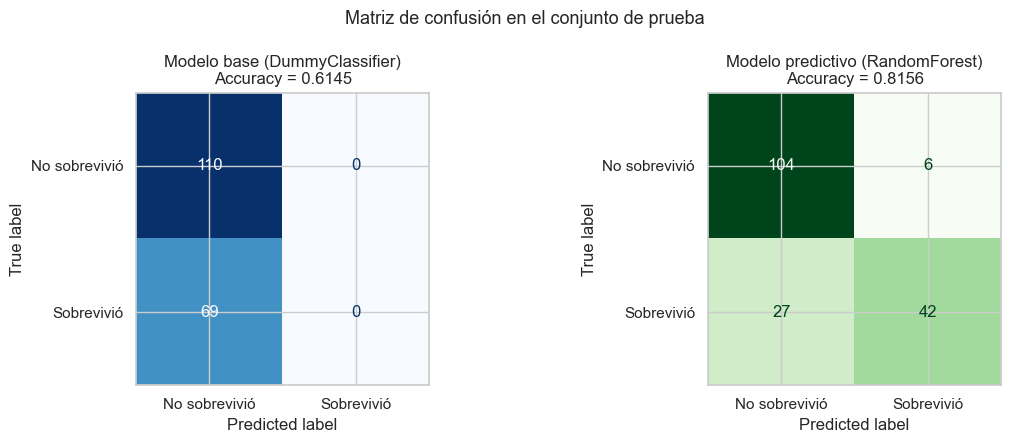

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_base,
    display_labels=["No sobrevivió", "Sobrevivió"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"Modelo base (DummyClassifier)\nAccuracy = {metricas_eval_base['accuracy']:.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_modelo,
    display_labels=["No sobrevivió", "Sobrevivió"],
    cmap="Greens",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"Modelo predictivo (RandomForest)\nAccuracy = {metricas_eval_modelo['accuracy']:.4f}")

plt.suptitle("Matriz de confusión en el conjunto de prueba", fontsize=13)
plt.tight_layout()
plt.show()


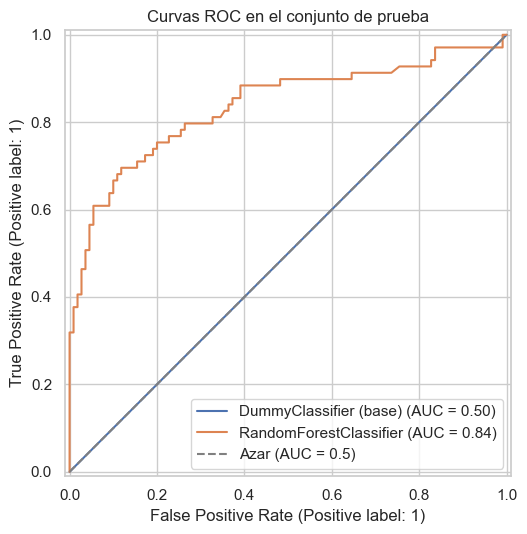

In [37]:
fig, ax = plt.subplots(figsize=(7, 5.5))

RocCurveDisplay.from_predictions(y_test, y_proba_base, name="DummyClassifier (base)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_modelo, name="RandomForestClassifier", ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar (AUC = 0.5)")
ax.set_title("Curvas ROC en el conjunto de prueba")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [38]:
metricas_base.update(metricas_eval_base)
metricas_modelo.update(metricas_eval_modelo)

Path("metricas_base.json").write_text(
    json.dumps(metricas_base, indent=2, ensure_ascii=False), encoding="utf-8"
)
Path("metricas_modelo.json").write_text(
    json.dumps(metricas_modelo, indent=2, ensure_ascii=False), encoding="utf-8"
)

print("Métricas de evaluación actualizadas en metricas_base.json y metricas_modelo.json")
print(json.dumps({"base": metricas_base, "modelo": metricas_modelo}, indent=2, ensure_ascii=False))


Métricas de evaluación actualizadas en metricas_base.json y metricas_modelo.json
{
  "base": {
    "modelo": "DummyClassifier",
    "estrategia": "most_frequent",
    "accuracy": 0.6145,
    "precision": 0.0,
    "recall": 0.0,
    "f1_score": 0.0,
    "roc_auc": 0.5
  },
  "modelo": {
    "modelo": "RandomForestClassifier",
    "estrategia": "Pipeline + GridSearchCV (StratifiedKFold 5)",
    "mejores_hiperparametros": {
      "clf__max_depth": 5,
      "clf__min_samples_leaf": 2,
      "clf__min_samples_split": 2,
      "clf__n_estimators": 100
    },
    "accuracy_cv": 0.8188,
    "accuracy": 0.8156,
    "precision": 0.875,
    "recall": 0.6087,
    "f1_score": 0.7179,
    "roc_auc": 0.8368
  }
}


### Justificación de la métrica principal: **F1-Score**

En el contexto del Titanic se elige el **F1-Score de la clase superviviente** como métrica
principal del proyecto, por las siguientes razones:

1. **La variable objetivo está desbalanceada** (~38.4% sobrevivió vs ~61.6% no sobrevivió).
   Con este desbalance, un modelo que siempre prediga *"no sobrevivió"* obtiene ~0.61 de
   accuracy sin aprender nada (justo lo que hace el modelo base). La accuracy por sí sola
   premia demasiado acertar la clase mayoritaria y puede ocultar un modelo que **no detecta
   a ningún superviviente**.
2. **El problema tiene dos tipos de error con distinto costo operativo.** Un *falso negativo*
   (predecir que no sobrevivió quien sí lo hizo) es perder a un superviviente potencial; un
   *falso positivo* (predecir supervivencia donde no la hubo) distorsiona la planificación de
   rescate. El F1-Score combina *precision* y *recall* de la clase positiva en una sola cifra,
   obligando al modelo a balancear ambos errores en lugar de optimizar uno a costa del otro.
3. **ROC-AUC se mantiene como métrica complementaria**, porque evalúa la calidad del
   *ranking* de probabilidades sin depender del umbral (0.5). Es útil para comparar modelos
   de forma robusta, pero no garantiza que, al umbralizar, se obtenga un buen balance
   precision/recall — que es lo que realmente importa al clasificar pasajeros.
4. **Accuracy se reporta como referencia de legibilidad**, siempre acompañada de la del
   modelo base, para que el lector no técnico pueda seguir la comparación.

**Criterio de éxito del proyecto:** el modelo predictivo debe superar al modelo base no solo
en accuracy, sino especialmente en **F1-Score** (que parte de **0.0**, porque el modelo base
nunca predice supervivencia) y en **ROC-AUC** (que parte de **0.5**, el valor del azar).


## Reflexión técnica

### 1. Limitaciones del modelo actual

- **Tamaño de datos reducido:** el conjunto de entrenamiento tiene solo 891 registros, por lo
  que las métricas en el test (179 registros) tienen una varianza alta: un pequeño cambio en
  la partición puede mover la accuracy varios puntos.
- **Recall de supervivientes todavía modesto:** el modelo predice correctamente ~61% de los
  supervivientes reales; el resto son falsos negativos, es decir, supervivientes que el modelo
  clasificaría como no supervivientes.
- **Variables poco explotadas:** `Name`, `Ticket` y `Cabin` se descartaron (`Cabin` tiene
  ~77% de valores faltantes) y `SibSp`/`Parch` se usan crudos, sin derivar el tamaño familiar.
- **Umbral fijo en 0.5:** no se ajustó el umbral de decisión al costo real de los errores,
  aunque el modelo entregue probabilidades calibradas (o no).
- **Un solo split para la evaluación final:** la estimación depende de una única partición
  train/test; no hay una estimación de la varianza de esa métrica fuera de la CV.

### 2. Dificultades encontradas

- **Valores faltantes** en `Age` (~20%), `Embarked` (2) y `Cabin` (~77%): se resolvió con
  imputación por mediana (numéricas) y moda (categóricas) **dentro del pipeline**, para que
  solo se calcule sobre cada pliegue de entrenamiento.
- **Evitar la fuga de información:** dividir *antes* de transformar y encadenar
  `ColumnTransformer` + clasificador en un único `Pipeline` fue la decisión clave; de lo
  contrario, la CV habría dado métricas optimistas.
- **Desbalance de clases:** un accuracy alta era fácil de conseguir sin aprender (modelo base
  ~0.61), lo que obligó a elegir métricas que sí penalizan no detectar supervivientes.
- **Codificación de categóricas:** `OneHotEncoder` con `handle_unknown="ignore"` para evitar
  errores si el test contiene categorías no vistas en train.
- **Tiempo de cómputo del `GridSearchCV`:** combinar 24 configuraciones × 5 pliegues exigió
  `n_jobs=-1` y un `max_depth` acotado para mantener el ajuste razonable.

### 3. Mejoras futuras

- **Ingeniería de características:** extraer el título del pasajero (`Mr`, `Mrs`, `Miss`,
  `Master`) desde `Name`, crear `FamilySize = SibSp + Parch + 1` y `IsAlone`, y usar la
  primera letra de `Cabin` como indicador de cubierta.
- **Ajuste del umbral de decisión:** optimizar el umbral sobre la curva ROC/PR maximizando
  F1 o según un costo específico de falsos negativos.
- **Más modelos y ensamble:** probar `GradientBoosting`, `HistGradientBoosting` o
  `LogisticRegression` (como referencia lineal calibrada) y comparar con validación cruzada.
- **Optimización más amplia:** `RandomizedSearchCV` o `HalvingGridSearchCV` sobre un espacio
  mayor de hiperparámetros, incluyendo `class_weight="balanced"`.
- **Validación más robusta:** repetir la evaluación con validación cruzada anidada o
  múltiples splits estratificados para reportar media ± desviación de las métricas finales.
- **Calibración de probabilidades** (`CalibratedClassifierCV`) si se necesita que las
  probabilidades sean interpretables como riesgo real, no solo como scores de ranking.
